# Misspecified Bayesian DRO experiment

The following experiment compares three different posteriors over two data-generating processes (DGPs) on the newsvendor problem.
The objective function is $G(x, \xi) = h \max (0, x - \xi) + b \max (0, \xi - x) + c x$ where $h = 3$, $b = 8$, $c = 0$.
The decision variable $0 \leq x \leq 50$ is continuous.
The customer demand $\xi$ has support $\Xi = \mathbb{R}^+$.


In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N=20$ points are the training samples and the last $M=50$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution given by the Bayesian DRO algorithm on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.


## Implementation details

In the following notebook, we concatenate all the CSV files together, then group by $\epsilon$ and the posterior method (`bayes`, `wll`, `mmd`):
- For each epsilon, posterior, & DGP, we save a CSV file where each row corresponds to a single replication $k$. The CSV contains the solution, time taken in seconds, out-of-sample mean $\mu^{(j)}(\epsilon)$, and out-of-sample variance $v^{(j)}(\epsilon)$.
- Each CSV file has a unique ID which maps to the `experiment.json` file. All the parameters can be found in the `experiment.csv` file.





In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers
from mis_dro.newsvendor import newsvendor_cost_cvxpy


In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1
num_observations = results_df["num_observations"]
num_test_observations = results_df["num_test_observations"]
results_df

mean_cost      var_cost  \
uuid                                 replication                             
680e0476-f2db-4d96-a213-3942c5596a89 0             71.338200   1877.593985   
                                     1            102.263323  32474.466263   
                                     2             59.619183   4474.581151   
                                     3             94.777515  14854.525125   
                                     4             99.306645  13496.165716   
...                                                      ...           ...   
46811520-40da-4242-bda6-d7392f018266 195          119.612638   1023.503374   
                                     196          127.189470    608.042652   
                                     197          115.586466    972.036920   
                                     198           78.583743    664.762526   
                                     199          124.991536   1732.909416   

                                                  solution  dgp_time  \
uuid                                 replication                       
680e0476-f2db-4d96-a213-3942c5596a89 0               34.45  0.000609   
                                     1               28.13  0.000522   
                                     2               23.73  0.000382   
                                     3               22.22  0.000394   
                                     4               35.70  0.000437   
...                                                    ...       ...   
46811520-40da-4242-bda6-d7392f018266 195             50.00  0.000643   
                                     196             50.00  0.000634   
                                     197             50.00  0.000636   
                                     198             35.36  0.000645   
                                     199             50.00  0.000633   

                                                  likelihood_time  \
uuid                                 replication                    
680e0476-f2db-4d96-a213-3942c5596a89 0                   0.012852   
                                     1                   0.011716   
                                     2                   0.011602   
                                     3                   0.011701   
                                     4                   0.013956   
...                                                           ...   
46811520-40da-4242-bda6-d7392f018266 195                 0.009017   
                                     196                 0.008642   
                                     197                 0.008969   
                                     198                 0.008905   
                                     199                 0.008904   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
680e0476-f2db-4d96-a213-3942c5596a89 0                  0.000200  563.059103   
                                     1                  0.000330  529.081552   
                                     2                  0.000172  511.974161   
                                     3                  0.000177  585.058361   
                                     4                  0.000215  575.859742   
...                                                          ...         ...   
46811520-40da-4242-bda6-d7392f018266 195               37.725969   79.259925   
                                     196               37.638553   77.054469   
                                     197               37.694951   77.224410   
                                     198               37.806478   77.862894   
                                     199               37.778487   77.476427   

                                                     algorithm  contamination  \
uuid                                 replication                               

In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost              \
                                                       mean         var   
algorithm    dgp              epsilon posterior                           
bayesian_dro contaminated_exp 0.001   bayes       63.542741  330.937458   
                                      mmd         46.179590   97.075924   
                                      wll         62.120195  306.461865   
                              0.002   bayes       64.318063  336.763605   
                                      mmd         46.449693   96.860238   
...                                                     ...         ...   
             truncated_normal 2.500   mmd        110.509128   25.770707   
                                      wll        103.296757  125.989845   
                              3.000   bayes      106.337972   92.916836   
                                      mmd        110.867028   18.703679   
                                      wll        105.800483   93.592659   

                                                    var_cost posterior_time  \
                                                        mean           mean   
algorithm    dgp              epsilon posterior                               
bayesian_dro contaminated_exp 0.001   bayes       969.473005       0.000142   
                                      mmd        1418.512036      57.302277   
                                      wll         988.711369       0.012479   
                              0.002   bayes       959.199675       0.000152   
                                      mmd        1390.737940      58.447617   
...                                                      ...            ...   
             truncated_normal 2.500   mmd         554.509852      53.969823   
                                      wll         551.601442       0.011635   
                              3.000   bayes       552.128826       0.000160   
                                      mmd         554.509852      50.937310   
                                      wll         552.618262       0.012959   

                                                 solve_time  solution  \
                                                       mean      mean   
algorithm    dgp              epsilon posterior                         
bayesian_dro contaminated_exp 0.001   bayes      400.385348  28.30455   
                                      mmd        377.579321  19.71680   
                                      wll        400.594969  27.70040   
                              0.002   bayes      394.627460  28.63970   
                                      mmd        346.244994  19.93845   
...                                                     ...       ...   
             truncated_normal 2.500   mmd        129.720777  49.71395   
                                      wll        128.222313  47.29885   
                              3.000   bayes      124.018832  48.31530   
                                      mmd        109.656118  49.83325   
                                      wll        117.466271  48.13765   

                                                            
                                                       var  
algorithm    dgp              epsilon posterior             
bayesian_dro contaminated_exp 0.001   bayes      64.338976  
                                      mmd        26.991291  
                                      wll        61.335975  
                              0.002   bayes      65.083377  
                                      mmd        26.810001  
...                                                    ...  
             truncated_normal 2.500   mmd         1.610724  
                                      wll        13.021787  
                              3.000   bayes       9.136372  
                                      mmd         0.869827  
                                      wll         9.252601  

[162 rows x 7 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated a

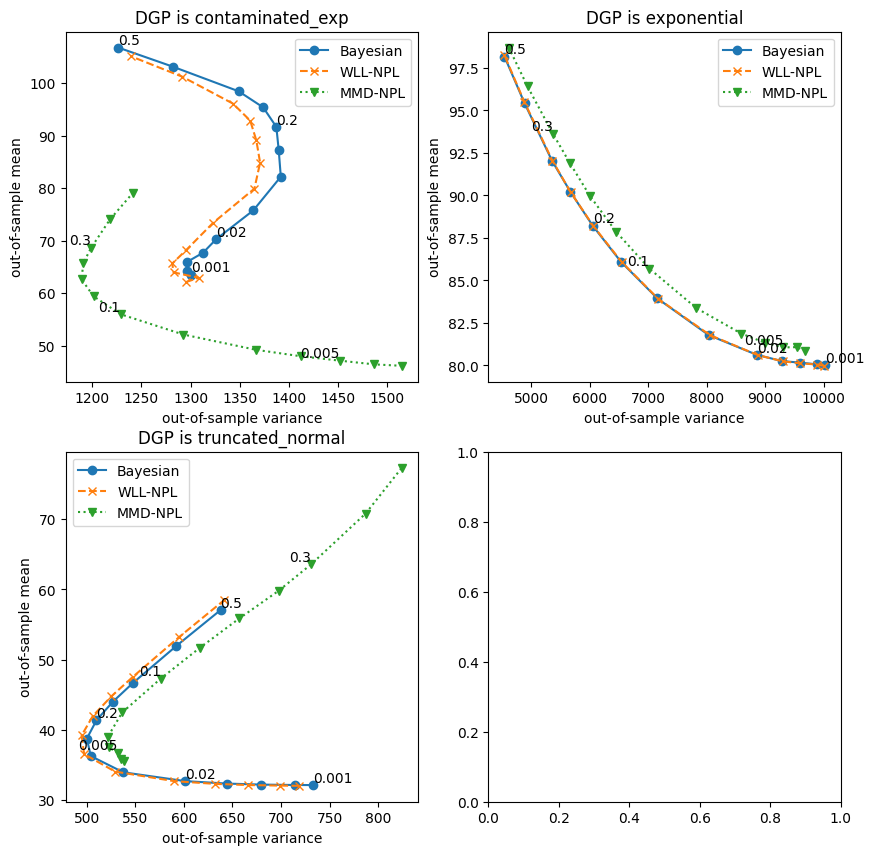

In [4]:
def plot_cost_mean_variance(df: pd.DataFrame, dgp: str, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    biggest_epsilon = 0.5
    idx = pd.IndexSlice
    bayes_df = df.loc[algorithm, dgp, :biggest_epsilon, "bayes"]
    wll_df = df.loc[algorithm, dgp, :biggest_epsilon, "wll"]
    mmd_df = df.loc[algorithm, dgp, :biggest_epsilon, "mmd"]

    # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    epsilon_list = [epsilon for epsilon in bayes_df.index.get_level_values("epsilon") if epsilon <= biggest_epsilon]

    for i, epsilon in enumerate(epsilon_list):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[:,:,epsilon,:], bayes_df["mean_cost"]["mean"][:,:,epsilon,:], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[:,:,epsilon,:], mmd_df["mean_cost"]["mean"][:,:,epsilon,:], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
dgp_list = list(agg_df.index.get_level_values("dgp").unique())
nrows = int(np.ceil(len(dgp_list)/2.0))
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
for i, dgp in enumerate(dgp_list):
    row = int(np.floor(i / 2.0))
    col = i % 2
    plot_cost_mean_variance(agg_df, dgp, axes[row][col])

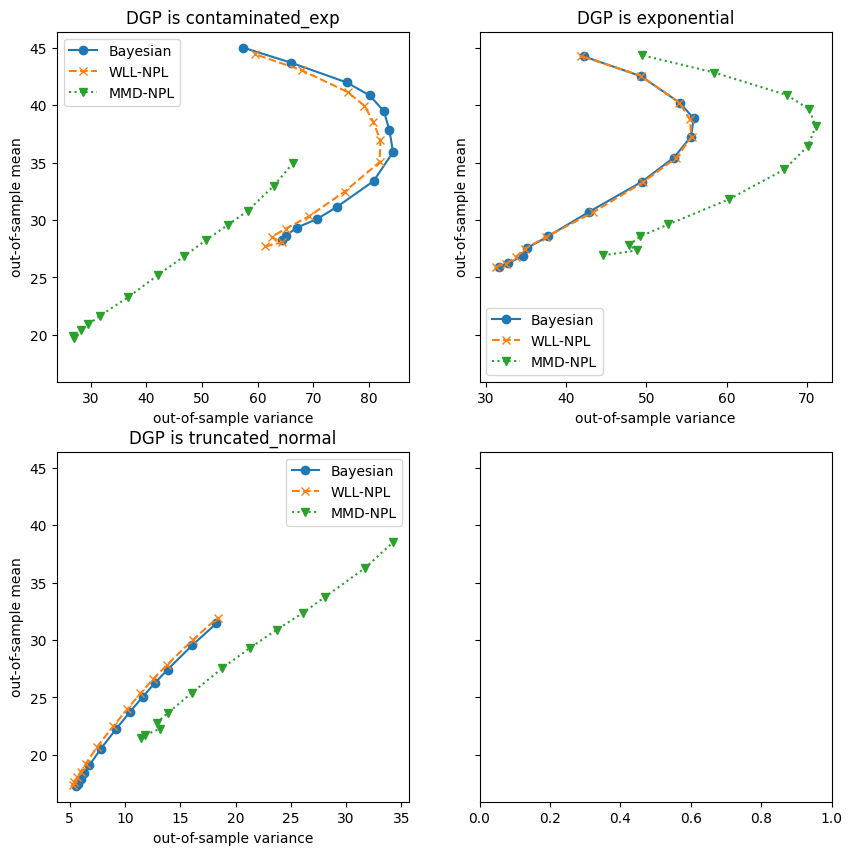

In [5]:
def plot_solution_mean_variance(df: pd.DataFrame, dgp: str, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    biggest_epsilon = 0.5
    bayes_df = df.loc[algorithm, dgp, :biggest_epsilon, "bayes"]
    wll_df = df.loc[algorithm, dgp, :biggest_epsilon, "wll"]
    mmd_df = df.loc[algorithm, dgp, :biggest_epsilon, "mmd"]

    # plot mean-variance trade-off
    axis.plot(bayes_df["solution"]["var"], bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_df["solution"]["var"], wll_df["solution"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_df["solution"]["var"], mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    epsilon_list = [epsilon for epsilon in bayes_df.index.get_level_values("epsilon") if epsilon <= biggest_epsilon]
    # for i, epsilon in enumerate(epsilon_list):
    #     if i % 4 == 0:
    #         axis.text(bayes_df["solution"]["var"][epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        # if (i+2) % 4 == 0:
        #     axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance of the solution x
dgp_list = list(agg_df.index.get_level_values("dgp").unique())
nrows = int(np.ceil(len(dgp_list)/2.0))
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=True, figsize=(10,10))
for i, dgp in enumerate(dgp_list):
    row = int(np.floor(i / 2.0))
    col = i % 2
    plot_solution_mean_variance(agg_df, dgp, axes[row][col])

## Solve time

Interestingly, the solve time (in seconds) for the Bayesian DRO algorithm doubles as $\epsilon \to 0$. 
The top row shows the solve time for two DGPs.
The bottom row shows the posterior sampling time for MMD, Bayes, and WLL.

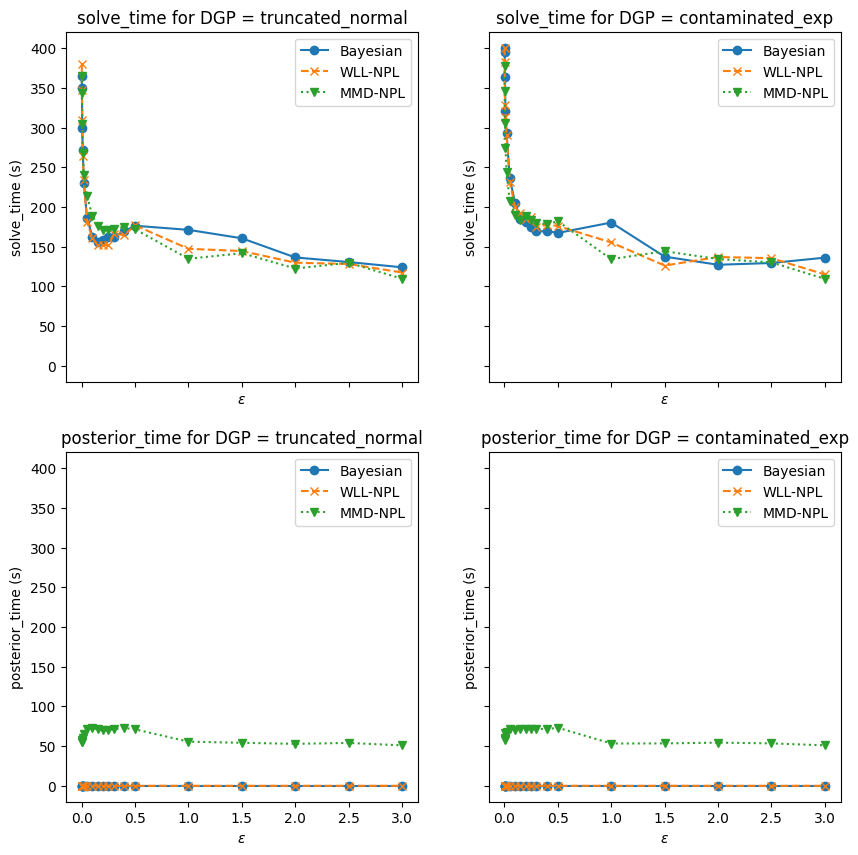

In [6]:
def plot_time_taken(df: pd.DataFrame, dgp: str, time_name: str, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    bayes_df = df.loc[algorithm, dgp, :, "bayes"]
    wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc[algorithm, dgp, :, "mmd"]
    
    axis.plot(bayes_df.index, bayes_df[time_name]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_df.index, wll_df[time_name]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_df.index, mmd_df[time_name]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")
    axis.set_title(f"{time_name} for DGP = {dgp}")
    axis.legend()
    axis.set_xlabel("$\epsilon$")
    axis.set_ylabel(f"{time_name} (s)")


fig, (row1, row2) = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10,10))
plot_time_taken(agg_df, "truncated_normal", "solve_time", row1[0])
plot_time_taken(agg_df, "contaminated_exp", "solve_time", row1[1])
plot_time_taken(agg_df, "truncated_normal", "posterior_time", row2[0])
plot_time_taken(agg_df, "contaminated_exp", "posterior_time", row2[1])

## Data-generating processes

We plot the density histograms from each of the DGPs.
Following from Section 4.1 of Shapiro et al. (2023), the truncated normal has mean 10 and variance 100, and is truncated above zero.
Again following from Section 4.1 of Shapiro et al. (2023), the exponential distribution has rate parameter $\lambda^{-1} = 20$, i.e. the mean is 20.

We introduce a contaminated exponential distribution with contamination level 0.2 where the contimination only affects the $N$ training samples.
That is, when sampling the training samples $\hat{\xi}_1,\ldots,\hat{\xi}_N$, 80% comes from the an exponential distribution $Exp(\lambda_1)$ with $\lambda^{-1}_1 = 10$ where as the other 20% of the data comes from an contaminating exponentional distribution $Exp(\lambda_2)$ with $\lambda^{-1}_2 = 70$.
However, the $M$ testing samples $\hat{\xi}_{N+1},\ldots,\hat{\xi}_{N+M}$ are all drawn from $Exp(\lambda_1)$.

In the below plots, the bottom-left plot shows the training data from the contaminated exponential distribution, where as the bottom-right shows the test data drawn only from $Exp(\lambda_1)$. 

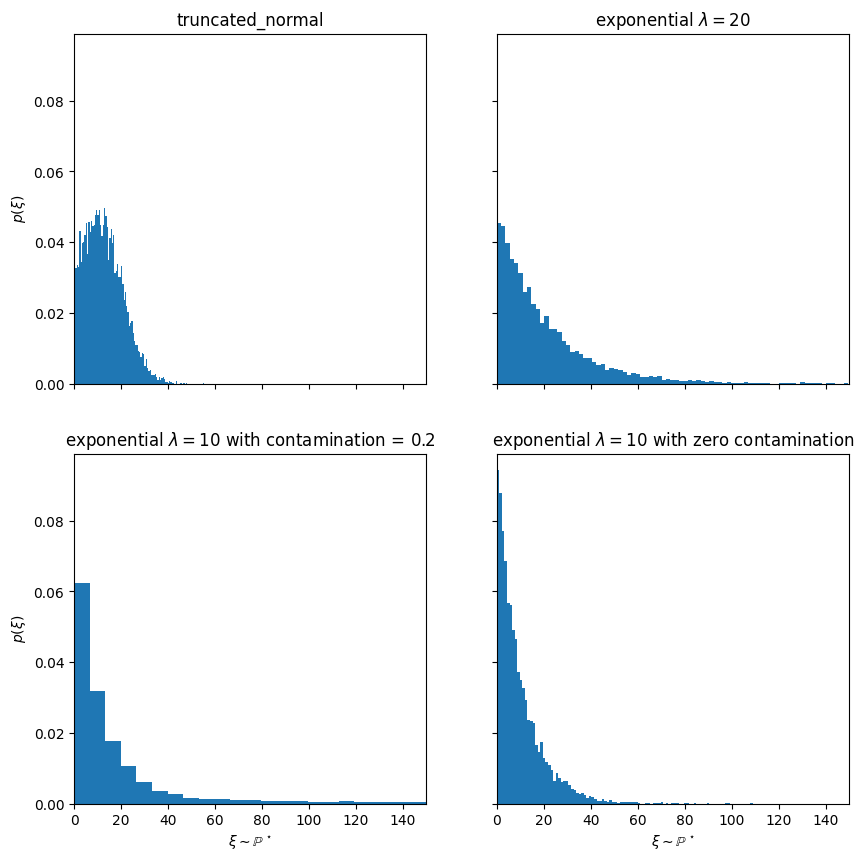

In [7]:
generator = np.random.default_rng(0)
nbins = 100
N = 10000

fig, axes = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10,10))

axes[0][0].hist(data_generation(N, random_state=generator), bins=nbins, label="truncated normal", density=True)
axes[0][1].hist(expon.rvs(scale=20.0, size=N, random_state=generator), bins=nbins,  label="exponential", density=True)
axes[1][0].hist(data_generation_outliers(N, contamination=0.2, random_state=generator), bins=nbins, label="contamination", density=True)
axes[1][1].hist(data_generation_outliers(N, contamination=0.0, random_state=generator), bins=nbins, density=True)
axes[0][0].set_title("truncated_normal")
axes[0][1].set_title("exponential $\lambda = 20$")
axes[1][0].set_title("exponential $\lambda = 10$ with contamination = 0.2")
axes[1][1].set_title("exponential $\lambda = 10$ with zero contamination")

axes[0][0].set_xlim(0, 150)

axes[1][0].set_xlabel(r"$\xi \sim \mathbb{P}^\star$")
axes[1][1].set_xlabel(r"$\xi \sim \mathbb{P}^\star$")
axes[0][0].set_ylabel(r"$p(\xi)$")
axes[1][0].set_ylabel(r"$p(\xi)$")

plt.show()

In [8]:
np.mean(data_generation(N, random_state=generator))

12.77386308685359

In [9]:
np.var(data_generation(N, random_state=generator))

61.33056103085002

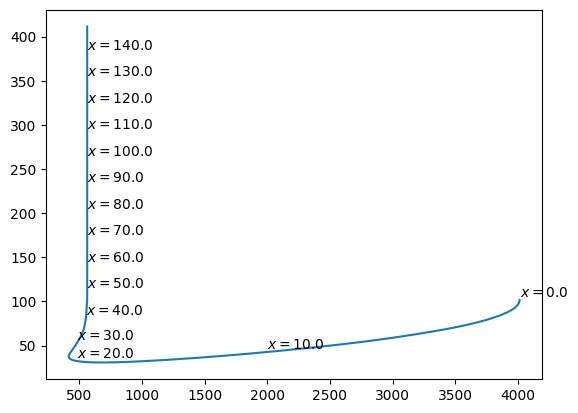

In [10]:
xi = data_generation(N, random_state=generator)
# xi = data_generation_outliers(N, contamination=0.2, random_state=generator)
# xi = expon.rvs(scale=20.0, size=N, random_state=generator)

x_upper = 150
mean_cost = [newsvendor_cost_cvxpy(x, xi).value.mean() for x in np.arange(0, x_upper, 0.1)]
var_cost = [newsvendor_cost_cvxpy(x, xi).value.var() for x in np.arange(0, x_upper, 0.1)]
plt.plot(var_cost, mean_cost)
for i, value in enumerate(list(np.arange(0,x_upper,0.1))):
    if i % 100 == 0:
        plt.text(var_cost[i], mean_cost[i], f"$x ={value}$", ha='left', va='bottom')

In [11]:
num_replications = 200
contamination = 0.2
in_sample_df = pd.DataFrame()
for params in experiment:
    in_sample_mean, in_sample_var = np.zeros(200), np.zeros(200)
    for j in range(num_replications):
        generator = np.random.default_rng(seed=j)
        if params["dgp"] == "truncated_normal":
            data = data_generation(params["num_observations"], random_state=generator)  # generate new observations
        elif params["dgp"] == "contaminated_exp":
            # specify contamination level for train data
            data = data_generation_outliers(params["num_observations"], contamination, random_state=generator)
        elif params["dgp"] == "exponential":
            data = expon.rvs(scale=20.0, size=params["num_observations"], random_state=generator)
        x = results_df.loc[(params["uuid"], j), "solution"]

        # now calculate the in-sample mean and variance!
        cost = newsvendor_cost_cvxpy(x, data).value
        in_sample_mean[j] = cost.mean()
        in_sample_var[j] = cost.var()
    in_sample_df = pd.concat([in_sample_df, pd.DataFrame({
        "uuid": [params["uuid"]] * num_replications,
        "replication": np.arange(num_replications),
        "mean_cost": in_sample_mean,
        "var_cost": in_sample_var,
    })])
in_sample_df



,uuid,replication,mean_cost,var_cost
0,680e0476-f2db-4d96-a213-3942c5596a89,0,120.823569,21011.464947
1,680e0476-f2db-4d96-a213-3942c5596a89,1,89.985345,16950.577171
2,680e0476-f2db-4d96-a213-3942c5596a89,2,67.974747,4631.331728
3,680e0476-f2db-4d96-a213-3942c5596a89,3,71.406217,5769.509167
4,680e0476-f2db-4d96-a213-3942c5596a89,4,105.817124,11848.913087
...,...,...,...,...
195,46811520-40da-4242-bda6-d7392f018266,195,163.764269,36693.538712
196,46811520-40da-4242-bda6-d7392f018266,196,130.284398,2204.680131
197,46811520-40da-4242-bda6-d7392f018266,197,156.940246,38313.309769
198,46811520-40da-4242-bda6-d7392f018266,198,87.869231,766.705136


In [12]:
in_sample_df.set_index(["uuid", "replication"], inplace=True)
experiment_df = pd.DataFrame(experiment).set_index("uuid")
in_sample_df = in_sample_df.join(experiment_df, on="uuid")
in_sample_df

mean_cost       var_cost  \
uuid                                 replication                              
680e0476-f2db-4d96-a213-3942c5596a89 0            120.823569   21011.464947   
                                     1             89.985345   16950.577171   
                                     2             67.974747    4631.331728   
                                     3             71.406217    5769.509167   
                                     4            105.817124   11848.913087   
...                                                      ...            ...   
46811520-40da-4242-bda6-d7392f018266 195          163.764269   36693.538712   
                                     196          130.284398    2204.680131   
                                     197          156.940246   38313.309769   
                                     198           87.869231     766.705136   
                                     199          192.929547  103830.311344   

                                                     algorithm  contamination  \
uuid                                 replication                                
680e0476-f2db-4d96-a213-3942c5596a89 0            bayesian_dro            0.0   
                                     1            bayesian_dro            0.0   
                                     2            bayesian_dro            0.0   
                                     3            bayesian_dro            0.0   
                                     4            bayesian_dro            0.0   
...                                                        ...            ...   
46811520-40da-4242-bda6-d7392f018266 195          bayesian_dro            0.2   
                                     196          bayesian_dro            0.2   
                                     197          bayesian_dro            0.2   
                                     198          bayesian_dro            0.2   
                                     199          bayesian_dro            0.2   

                                                               dgp  epsilon  \
uuid                                 replication                              
680e0476-f2db-4d96-a213-3942c5596a89 0                 exponential    0.001   
                                     1                 exponential    0.001   
                                     2                 exponential    0.001   
                                     3                 exponential    0.001   
                                     4                 exponential    0.001   
...                                                            ...      ...   
46811520-40da-4242-bda6-d7392f018266 195          contaminated_exp    3.000   
                                     196          contaminated_exp    3.000   
                                     197          contaminated_exp    3.000   
                                     198          contaminated_exp    3.000   
                                     199          contaminated_exp    3.000   

                                                  lengthscale  \
uuid                                 replication                
680e0476-f2db-4d96-a213-3942c5596a89 0                   -1.0   
                                     1                   -1.0   
                                     2                   -1.0   
                                     3                   -1.0   
                                     4                   -1.0   
...                                                       ...   
46811520-40da-4242-bda6-d7392f018266 195                 -1.0   
                                     196                 -1.0   
                                     197                 -1.0   
                                     198                 -1.0   
                                     199                 -1.0   

                                                  num_likelihood_samples  \
uuid               

In [13]:
in_sample_gb = in_sample_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
in_df = in_sample_gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
})
in_df

mean_cost               \
                                                       mean          var   
algorithm    dgp              epsilon posterior                            
bayesian_dro contaminated_exp 0.001   bayes      123.104122  2769.261008   
                                      mmd        116.585160  2164.687936   
                                      wll        122.404958  2731.813991   
                              0.002   bayes      123.438912  2776.086997   
                                      mmd        116.618442  2161.091613   
...                                                     ...          ...   
             truncated_normal 2.500   mmd        109.752510    24.904709   
                                      wll        102.507210    53.679572   
                              3.000   bayes      105.556560    42.422190   
                                      mmd        110.110410    24.008357   
                                      wll        105.023610    39.943740   

                                                     var_cost  
                                                         mean  
algorithm    dgp              epsilon posterior                
bayesian_dro contaminated_exp 0.001   bayes      57343.441007  
                                      mmd        72690.334569  
                                      wll        58255.064710  
                              0.002   bayes      56955.464302  
                                      mmd        72419.944814  
...                                                       ...  
             truncated_normal 2.500   mmd          582.438814  
                                      wll          582.438814  
                              3.000   bayes        582.438814  
                                      mmd          582.438814  
                                      wll          582.438814  

[162 rows x 3 columns]

/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg20/u1508153/.conda/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated a

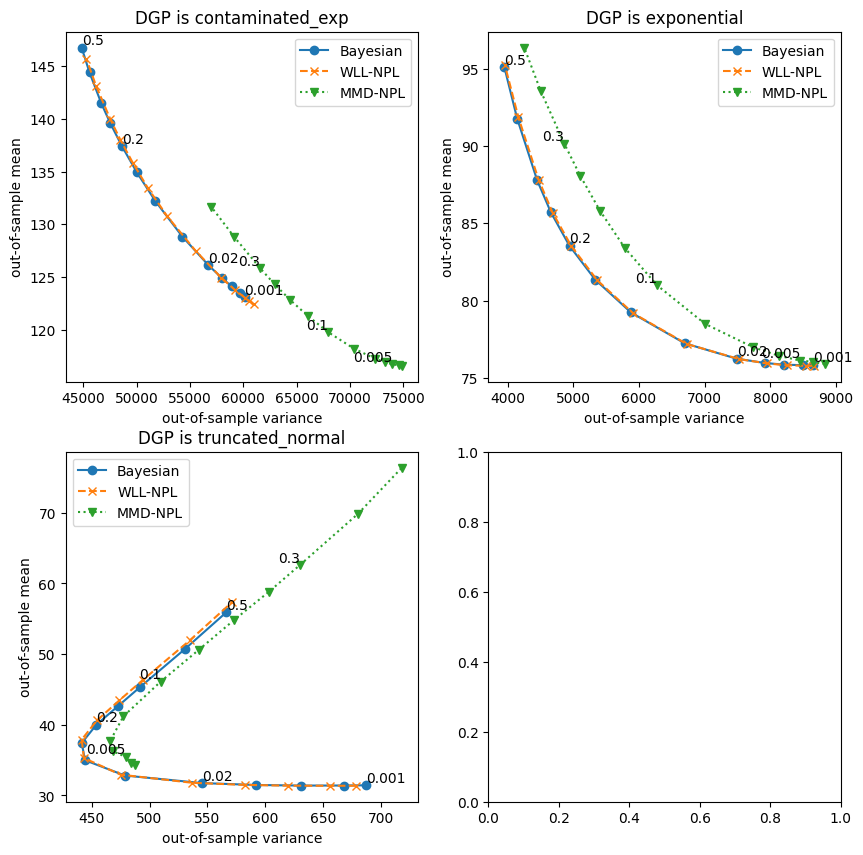

In [14]:
# plot mean-variance trade-off for each DGP
dgp_list = list(in_df.index.get_level_values("dgp").unique())
nrows = int(np.ceil(len(dgp_list)/2.0))
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
for i, dgp in enumerate(dgp_list):
    row = int(np.floor(i / 2.0))
    col = i % 2
    plot_cost_mean_variance(in_df, dgp, axes[row][col])